In [12]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from pathlib import Path

In [13]:
# Dataset paths
train_dir = Path("../data/Training")
test_dir = Path("../data/Testing")

# Image settings - need to be default for the CNN
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [14]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 5524 files belonging to 4 classes.
Using 4420 files for training.
Found 5524 files belonging to 4 classes.
Using 1104 files for validation.


In [15]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 554 files belonging to 4 classes.


In [16]:
class_names = train_ds.class_names
print(class_names)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [17]:
normalization_layer = layers.Rescaling(1./255)

train_ds_normalized = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds_normalized = val_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds_normalized = test_ds.map(lambda x, y: (normalization_layer(x), y))

In [18]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds_normalized = train_ds_normalized.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds_normalized = val_ds_normalized.cache().prefetch(buffer_size=AUTOTUNE)
test_ds_normalized = test_ds_normalized.cache().prefetch(buffer_size=AUTOTUNE)

In [19]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

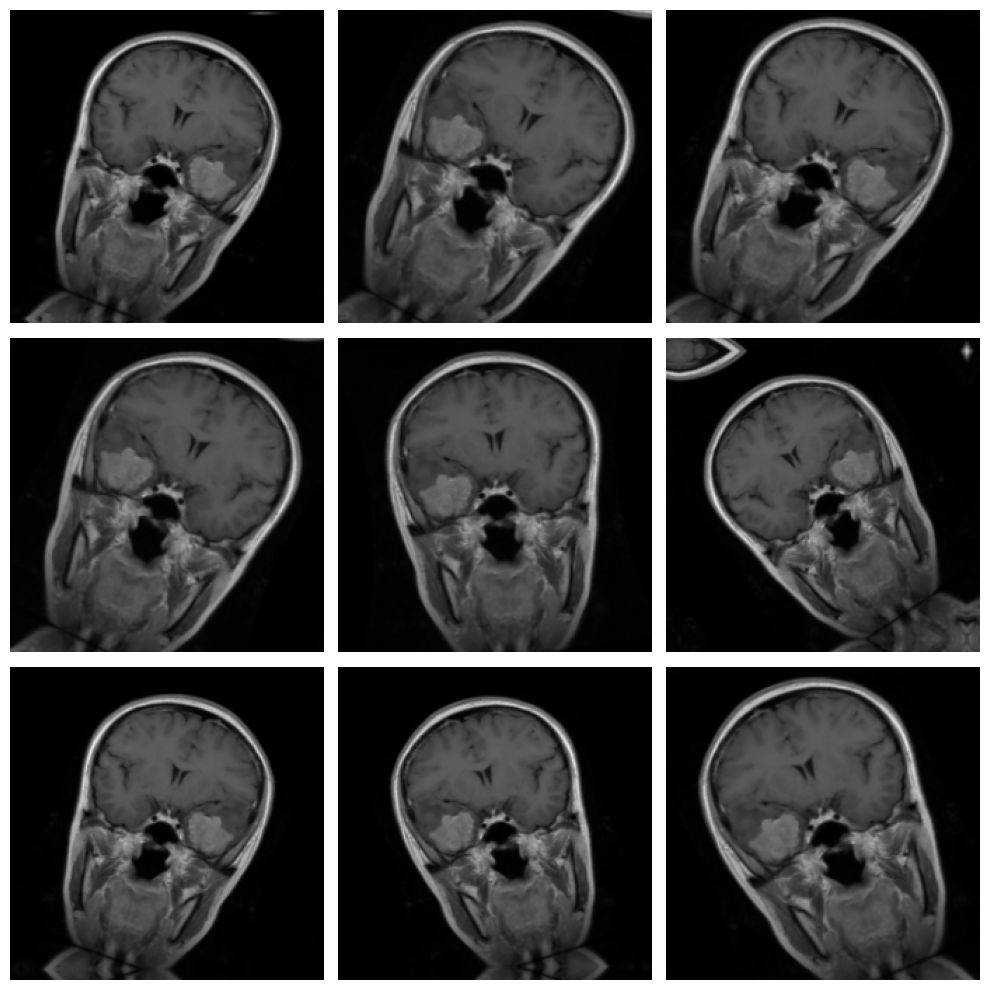

In [20]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    first_image = images[0]
    
    for i in range(9):
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        
        plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_image[0].numpy().astype("uint8"), cmap="gray")
        plt.axis("off")

plt.tight_layout()
plt.show()

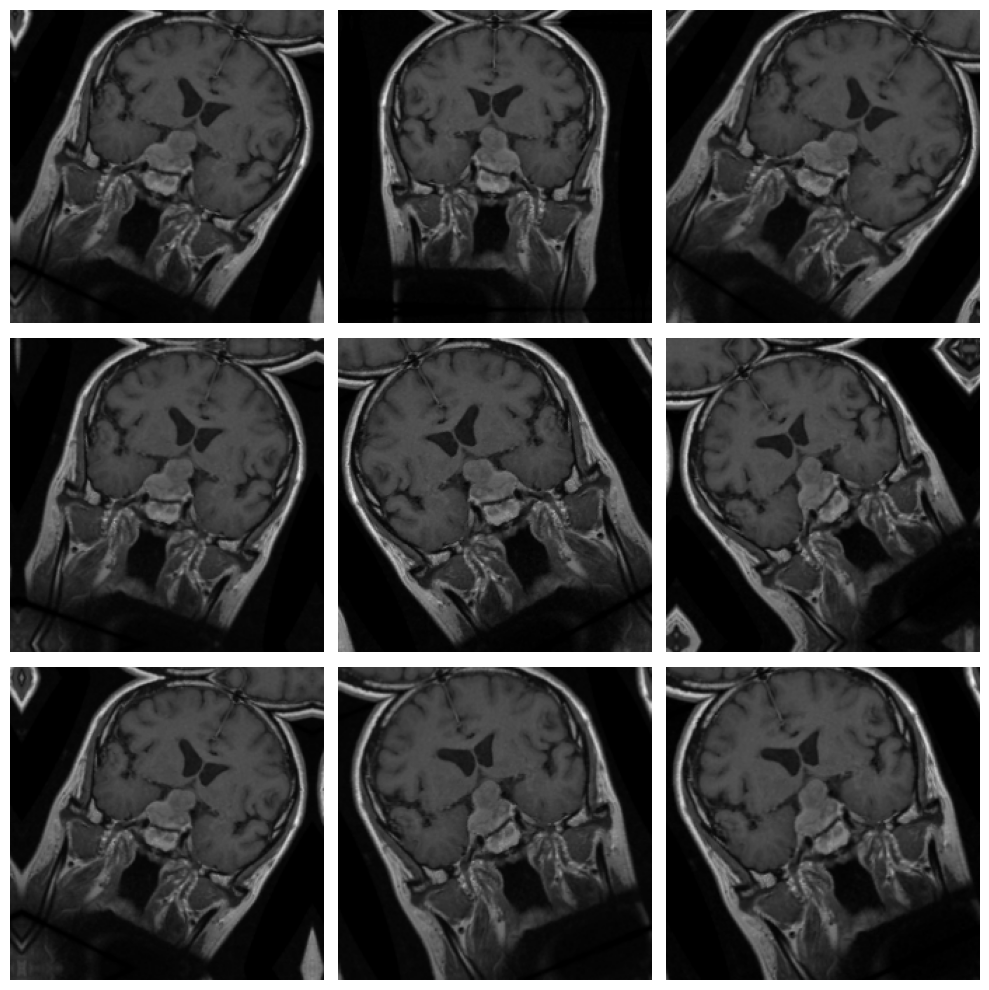

In [21]:
plt.figure(figsize=(10, 10))

try:
    images, labels = next(iter(train_ds.take(1)))
    first_image = images[0]

    for i in range(9):
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0), training=True)

        plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_image[0].numpy().astype("uint8"), cmap="gray")
        plt.axis("off")

    plt.tight_layout()
    plt.savefig("../figures/augmentation_examples.png", dpi=300)
    plt.show()

except Exception as e:
    print("Dataset loading failed:")
    print(e)

## Preprocessing and Augmentation Summary

In this notebook, MRI images were resized to 224x224 pixels, labels were automatically encoded from folder names, and pixel values were normalized from the original 0–255 range to 0–1. The training set was split into training and validation subsets, while the testing set was kept separate for final evaluation. A data augmentation pipeline was also created using horizontal flipping, rotation, zoom, and contrast adjustments to improve model generalization.
